# TSEncoder Blood Glucose Prediction from PPG Signals

This notebook implements **end-to-end supervised training** for non-invasive glucose monitoring:

**Single-Stage Training**: TSEncoder (Dilated Convolutions) + Regression Head trained directly on labeled glucose data with MSE loss

**Architecture**: TSEncoder (Dilated Convolutions)  
**Target Performance**: RMSE < 20 mg/dL, MAE < 15 mg/dL  
**Dataset**: VitalDB

Based on: "Non-invasive blood glucose monitoring using PPG signals" (2024)

## 0. Setup Environment

In [1]:
# Clone repository with submodules (ts2vec is a submodule)
!cd /kaggle/working && rm -rf 3x1-PPG
!git clone --recurse-submodules -b dl-model --single-branch https://github.com/omar-A-hassan/3x1-PPG.git
!ls -la /kaggle/working/3x1-PPG/src/
!ls -la /kaggle/working/3x1-PPG/ts2vec/


Cloning into '3x1-PPG'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 142 (delta 60), reused 114 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 363.92 KiB | 8.88 MiB/s, done.
Resolving deltas: 100% (60/60), done.
Submodule 'ts2vec' (https://github.com/zhihanyue/ts2vec.git) registered for path 'ts2vec'
Cloning into '/kaggle/working/3x1-PPG/ts2vec'...
remote: Enumerating objects: 133, done.        
remote: Counting objects: 100% (39/39), done.        
remote: Compressing objects: 100% (18/18), done.        
remote: Total 133 (delta 23), reused 21 (delta 21), pack-reused 94 (from 1)        
Receiving objects: 100% (133/133), 37.01 KiB | 9.25 MiB/s, done.
Resolving deltas: 100% (67/67), done.
Submodule path 'ts2vec': checked out 'b0088e14a99706c05451316dc6db8d3da9351163'
total 28
drwxr-xr-x 6 root root 4096 Oct 11 23:55 .
drwxr-xr-x 6 root root 4096 Oct 11 23:

In [2]:
# Install dependencies from requirements.txt
!pip install -r /kaggle/working/3x1-PPG/requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Add repos to path
sys.path.insert(0, '/kaggle/working/3x1-PPG')
sys.path.insert(0, '/kaggle/working/ts2vec')

# Import our modules
from src.models import TSEncoderPPGRegressor, build_tsencoder_ppg, TS2VEC_AVAILABLE
from src.preprocessing import PPGPreprocessor
from src.training import Trainer
from src.evaluation import compute_all_metrics, print_metrics, clarke_error_grid_analysis

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"TS2Vec available: {TS2VEC_AVAILABLE}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    

PyTorch version: 2.6.0+cu124
CUDA available: True
TS2Vec available: True
CUDA device: Tesla P100-PCIE-16GB


## 1. Load VitalDB Dataset

Following the paper's methodology:
- 16-minute PPG windows (±8 min around glucose measurement)
- Downsampled to 100 Hz
- 1-second segments centered on systolic/diastolic peaks

In [4]:
# Load VitalDB dataset
import vitaldb
from tqdm import tqdm

# Load laboratory glucose data
df_labs = pd.read_csv('https://api.vitaldb.net/labs')
glucose_labs = df_labs[df_labs['name'] == 'gluc'].copy()
print(f"Found {len(glucose_labs)} glucose measurements")

# Find cases with both PPG and glucose
ppg_cases = set(vitaldb.find_cases(['SNUADC/PLETH']))
glucose_cases = set(glucose_labs['caseid'].unique())
common_cases = list(ppg_cases & glucose_cases)
print(f"Found {len(common_cases)} cases with both PPG and glucose\n")

# Limit for faster training (increase for full dataset)
MAX_CASES = 100
if len(common_cases) > MAX_CASES:
    common_cases = np.random.choice(common_cases, MAX_CASES, replace=False).tolist()
    print(f"Using {MAX_CASES} cases for training")

Found 35358 glucose measurements
Found 4872 cases with both PPG and glucose

Using 100 cases for training


In [5]:
# Extract PPG-glucose pairs
ppg_signals = []
glucose_values = []
patient_ids = []
sampling_rate = 100  # Downsample to 100Hz

WINDOW_MINUTES = 16
WINDOW_SECONDS = WINDOW_MINUTES * 60
WINDOW_SAMPLES = WINDOW_SECONDS * sampling_rate  # 96,000 samples

for caseid in tqdm(common_cases, desc="Loading cases"):
    try:
        vals = vitaldb.load_case(caseid, ['SNUADC/PLETH'], 1/sampling_rate)
        if vals is None or len(vals) == 0:
            continue
        
        ppg_track = vals[:, 0]
        case_glucose = glucose_labs[glucose_labs['caseid'] == caseid]
        
        for _, glucose_row in case_glucose.iterrows():
            glucose_value = glucose_row['result']
            if glucose_value < 40 or glucose_value > 600:
                continue
            
            glucose_idx = int(glucose_row['dt'] * sampling_rate)
            half_window = WINDOW_SAMPLES // 2
            window_start = glucose_idx - half_window
            window_end = glucose_idx + half_window
            
            if window_start < 0 or window_end > len(ppg_track):
                continue
            
            ppg_window = ppg_track[window_start:window_end]
            if np.isnan(ppg_window).sum() / len(ppg_window) > 0.5:
                continue
            
            ppg_signals.append(ppg_window)
            glucose_values.append(glucose_value)
            patient_ids.append(caseid)
    except:
        continue

ppg_signals = np.array(ppg_signals)
glucose_values = np.array(glucose_values)
patient_ids = np.array(patient_ids)

print(f"\nDataset loaded: {len(ppg_signals)} samples from {len(np.unique(patient_ids))} patients")
print(f"Glucose range: {glucose_values.min():.1f} - {glucose_values.max():.1f} mg/dL")

Loading cases: 100%|██████████| 100/100 [03:45<00:00,  2.25s/it]


Dataset loaded: 149 samples from 67 patients
Glucose range: 58.0 - 274.0 mg/dL


## 2. Preprocess PPG Signals

Extract 1-second segments centered on peaks for end-to-end training

In [6]:
# Initialize preprocessor
preprocessor = PPGPreprocessor(
    sampling_rate=sampling_rate,
    segment_length=1.0,
    lowcut=0.5,
    highcut=8.0,
    peak_height_threshold=20,
    peak_distance_factor=0.8,
    similarity_threshold=0.85
)

processed_segments = []
processed_glucose = []
processed_patient_ids = []

MAX_SEGMENTS_PER_MEASUREMENT = 200

for ppg_window, glucose, patient_id in tqdm(zip(ppg_signals, glucose_values, patient_ids), total=len(ppg_signals)):
    segments = preprocessor.preprocess(ppg_window, apply_template_matching=True)
    
    if segments is None or len(segments) == 0:
        continue
    
    # Subsample to match paper's approach
    if len(segments) > MAX_SEGMENTS_PER_MEASUREMENT:
        indices = np.random.choice(len(segments), MAX_SEGMENTS_PER_MEASUREMENT, replace=False)
        segments = [segments[i] for i in sorted(indices)]
    
    for segment in segments:
        processed_segments.append(segment)
        processed_glucose.append(glucose)
        processed_patient_ids.append(patient_id)

X = np.array(processed_segments, dtype=np.float32)
y = np.array(processed_glucose, dtype=np.float32)
patient_ids_processed = np.array(processed_patient_ids)

print(f"\nPreprocessed: {len(X)} 1-second segments")
print(f"Unique patients: {len(np.unique(patient_ids_processed))}")

100%|██████████| 149/149 [00:01<00:00, 83.61it/s]


Preprocessed: 17297 1-second segments
Unique patients: 60


## 3. Train/Val/Test Split by Patient

In [7]:
from sklearn.model_selection import train_test_split

unique_patients = np.unique(patient_ids_processed)
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)
train_patients, val_patients = train_test_split(train_patients, test_size=0.2, random_state=42)

train_mask = np.isin(patient_ids_processed, train_patients)
val_mask = np.isin(patient_ids_processed, val_patients)
test_mask = np.isin(patient_ids_processed, test_patients)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)} samples from {len(train_patients)} patients")
print(f"Val: {len(X_val)} samples from {len(val_patients)} patients")
print(f"Test: {len(X_test)} samples from {len(test_patients)} patients")

Train: 10981 samples from 38 patients
Val: 3111 samples from 10 patients
Test: 3205 samples from 12 patients


## 4. Build End-to-End TSEncoder Model

Create TSEncoder with regression head for direct supervised training on glucose labels

In [8]:
# Build end-to-end TSEncoder model
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = build_tsencoder_ppg(
    input_dims=1,
    output_dims=320,
    hidden_dims=64,
    depth=10,
    dropout=0.1
).to(device)

# Print model info
param_counts = model.count_parameters()
print(f"TSEncoder Model Built Successfully!")
print(f"Total parameters: {param_counts['total']:,}")
print(f"Trainable parameters: {param_counts['trainable']:,}")
print(f"Encoder parameters: {param_counts['encoder']:,}")
print(f"Regression head parameters: {param_counts['regression_head']:,}")
print(f"Device: {device}")

TSEncoder Model Built Successfully!
Total parameters: 701,569
Trainable parameters: 701,569
Encoder parameters: 637,248
Regression head parameters: 64,321
Device: cuda


## 5. Train Model (End-to-End Supervised Learning)

In [9]:
# Prepare data tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

# Create data loaders
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Train the model
from src.training import Trainer

trainer = Trainer(
    model=model,
    device=device,
    learning_rate=0.0005,
    weight_decay=0.01
)

trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=200,
    early_stopping_patience=30,
    save_dir='/kaggle/working/checkpoints',
    verbose=True
)

print(f"\nTraining completed!")
print(f"Best epoch: {trainer.best_epoch + 1}")
print(f"Best val loss: {trainer.best_val_loss:.4f}")
print(f"Best val MAE: {trainer.history['val_mae'][trainer.best_epoch]:.2f} mg/dL")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/200
  Train Loss: 3790.4781, Train MAE: 45.17 mg/dL
  Val Loss: 17593.3691, Val MAE: 113.56 mg/dL
  LR: 0.000500
  → Best model saved (Val MAE: 113.56 mg/dL)
Epoch 2/200
  Train Loss: 2003.8082, Train MAE: 33.40 mg/dL
  Val Loss: 3073.7681, Val MAE: 43.84 mg/dL
  LR: 0.000500
  → Best model saved (Val MAE: 43.84 mg/dL)
Epoch 3/200
  Train Loss: 1875.9605, Train MAE: 32.99 mg/dL
  Val Loss: 3152.0018, Val MAE: 51.77 mg/dL
  LR: 0.000500
Epoch 4/200
  Train Loss: 1825.9031, Train MAE: 32.82 mg/dL
  Val Loss: 1029.1703, Val MAE: 26.56 mg/dL
  LR: 0.000500
  → Best model saved (Val MAE: 26.56 mg/dL)
Epoch 5/200
  Train Loss: 1828.2073, Train MAE: 32.67 mg/dL
  Val Loss: 599.6165, Val MAE: 19.93 mg/dL
  LR: 0.000500
  → Best model saved (Val MAE: 19.93 mg/dL)
Epoch 6/200
  Train Loss: 1838.4832, Train MAE: 32.44 mg/dL
  Val Loss: 1104.3560, Val MAE: 27.58 mg/dL
  LR: 0.000500
Epoch 7/200
  Train Loss: 1803.2951, Train MAE: 32.10 mg/dL
  Val Loss: 1672.2351, Val MAE: 35.93 mg/dL
  LR

## 6. Evaluate Model Performance

In [10]:
# Load best model
trainer.load_checkpoint('/kaggle/working/checkpoints/best_model.pt')

# Predictions
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_pred = model(X_test_tensor).cpu().numpy().squeeze()

# Compute metrics
metrics = compute_all_metrics(y_test, y_pred)
print_metrics(metrics)

Loaded checkpoint from epoch 21
Val MAE: 16.75 mg/dL
EVALUATION METRICS
RMSE:  33.89 mg/dL
MAE:   27.33 mg/dL
MAPE:  23.26%
R²:    0.0074

Clarke Error Grid Analysis:
  Zone A: 48.4%
  Zone B: 51.6%
  Zone C: 0.0%
  Zone D: 0.0%
  Zone E: 0.0%


Clarke Error Grid saved to /kaggle/working/clarke_error_grid.png


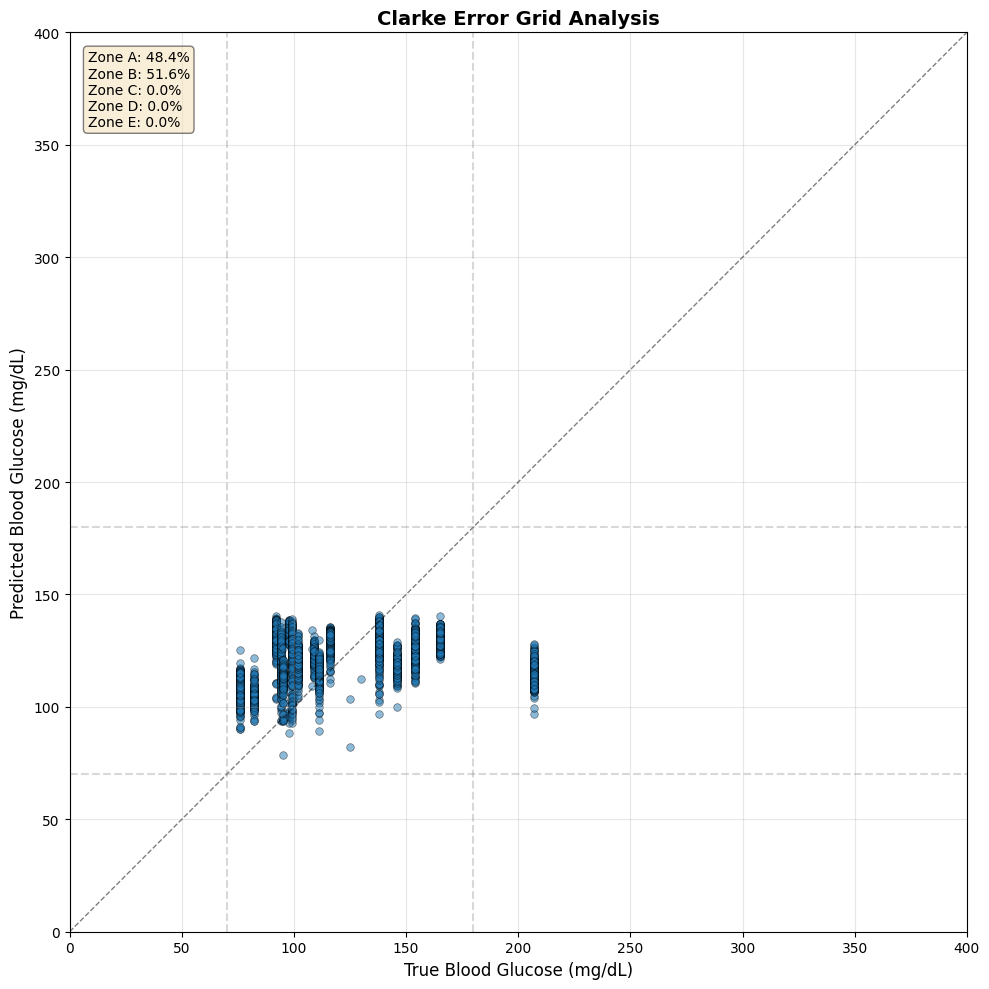

{'A': 48.39313572542901, 'B': 51.60686427457099, 'C': 0.0, 'D': 0.0, 'E': 0.0}

In [11]:
clarke_error_grid_analysis(
    y_test,
    y_pred,
    show_plot=True,
    save_path='/kaggle/working/clarke_error_grid.png'
)

## 7. Visualize Results

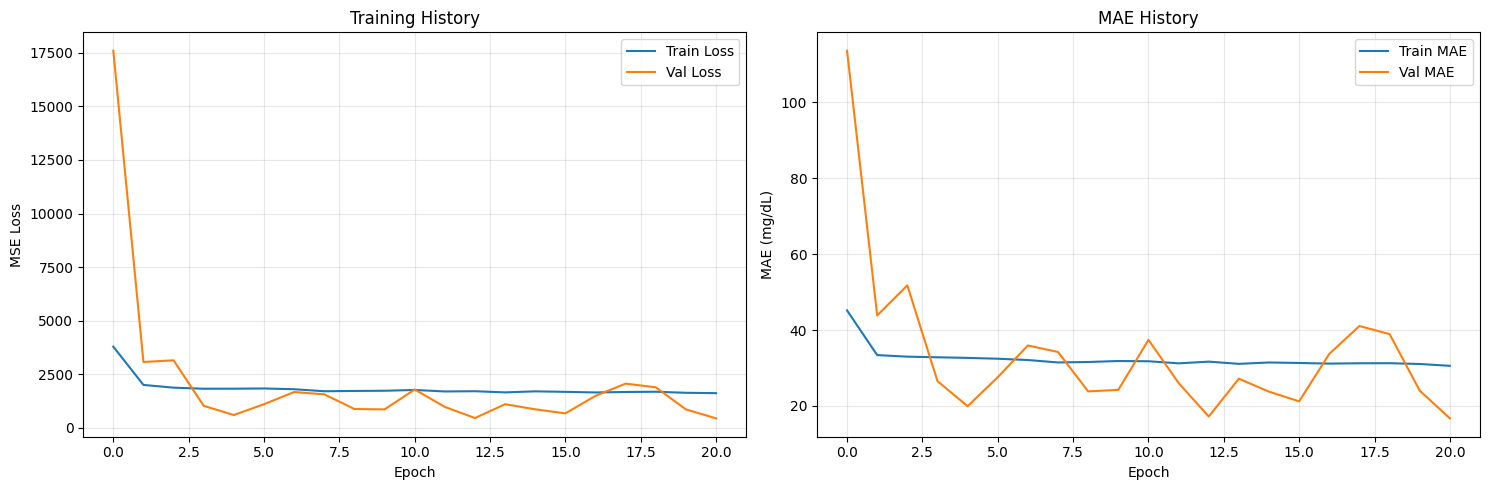

Best validation MAE: 16.75 mg/dL


In [12]:
# Training history
history = trainer.history

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_mae'], label='Train MAE')
axes[1].plot(history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (mg/dL)')
axes[1].set_title('MAE History')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=300)
plt.show()

print(f"Best validation MAE: {min(history['val_mae']):.2f} mg/dL")

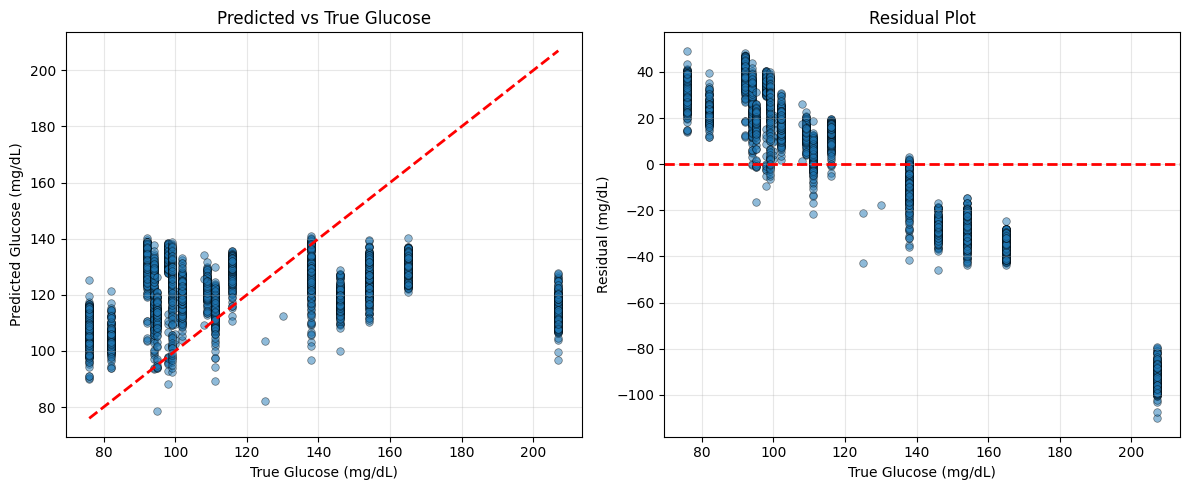

In [13]:
# Predictions plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, s=30, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('True Glucose (mg/dL)')
plt.ylabel('Predicted Glucose (mg/dL)')
plt.title('Predicted vs True Glucose')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_pred - y_test
plt.scatter(y_test, residuals, alpha=0.5, s=30, edgecolors='k', linewidths=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('True Glucose (mg/dL)')
plt.ylabel('Residual (mg/dL)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/predictions.png', dpi=300)
plt.show()